In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils.data_utils import MoonsDataHelper
import warnings
import math
from utils.evaluation_utils import EvaluationHelper
warnings.filterwarnings("ignore")

## Data Visualization

In [2]:
x_train, x_test, y_train, y_test = MoonsDataHelper.load_dataset()
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1600, 2), (400, 2), (1600,), (400,))

In [3]:
x_train.head()

,Feature_1,Feature_2
1860,1.216889,-0.627630
353,1.216012,-0.401308
1333,-0.617450,1.005901
905,1.625030,-0.216752
1289,0.798015,0.056454


In [4]:
y_train.head()

1860    1
353     1
1333    0
905     1
1289    0
Name: Class_1, dtype: int64

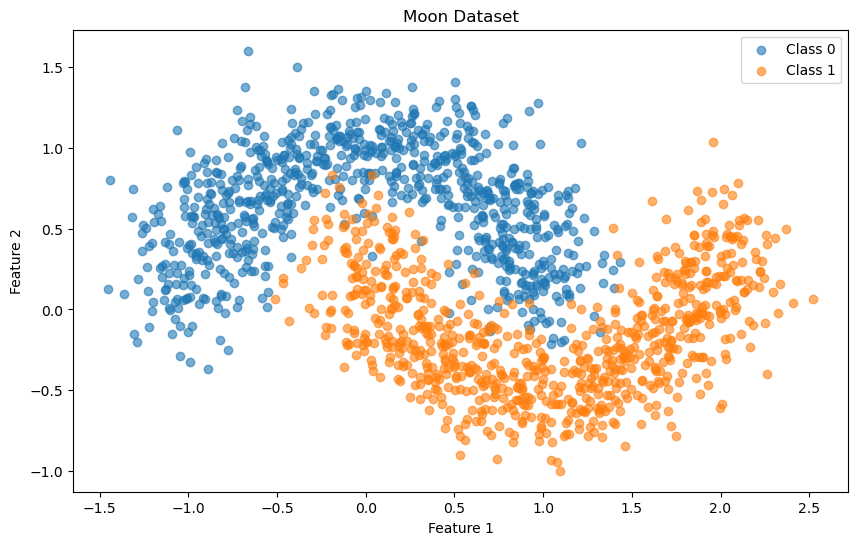

In [5]:
MoonsDataHelper.plot_moons(x_train, y_train)

## Model Building

In [6]:
x_train = np.array(x_train)
x_test = np.array(x_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [7]:
def predict(x, k=5):
    distances = []
    
    for i in range (len(x_train)):
        distances.append({"idx": i, "dist": math.dist(x, x_train[i])})
    
    distances = sorted(distances, key=lambda d: d["dist"])
    neighbors = distances[:k]
    
    neighbor_indices = [neighbor["idx"] for neighbor in neighbors]
    neighbor_labels = y_train[neighbor_indices]
    
    values, counts = np.unique(neighbor_labels, return_counts=True)
    
    return values[np.argmax(counts)]

## Model Evaluation

In [8]:
predictions = []

for x in x_test:
    prediction = predict(x, 4)
    predictions.append(prediction)

predictions = np.array(predictions)

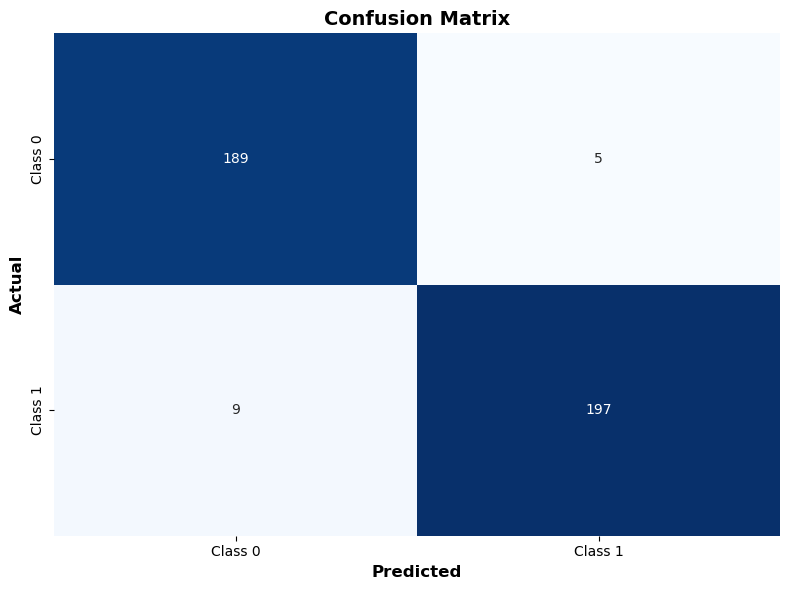

True Negatives: 189
False Positives: 5
False Negatives: 9
True Positives: 197

Sensitivity (Recall): 0.9563
Specificity: 0.9742
Precision: 0.9752
Accuracy: 0.9650
F1 Score: 0.9657


In [9]:
EvaluationHelper.plot_confusion_matrix(y_test, predictions, class_names=["Class 0", "Class 1"])

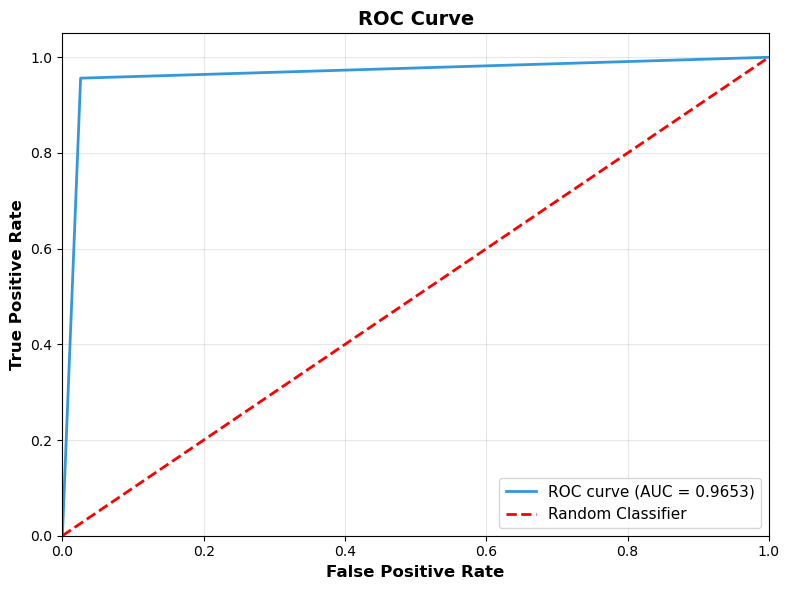

Area Under the Curve (AUC): 0.9653


In [10]:
EvaluationHelper.plot_roc_curve(y_test, predictions)

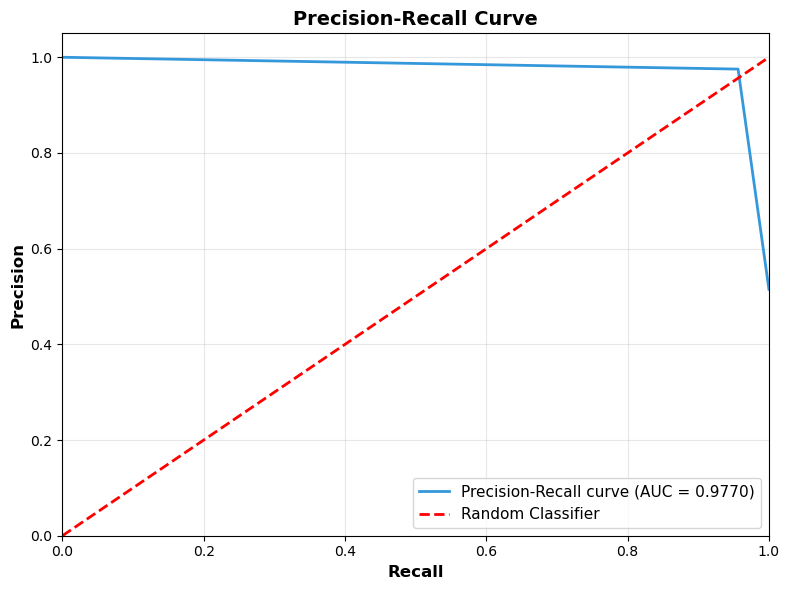

Area Under the Curve (AUC): 0.9770


In [11]:
EvaluationHelper.plot_precision_recall_curve(y_test, predictions)

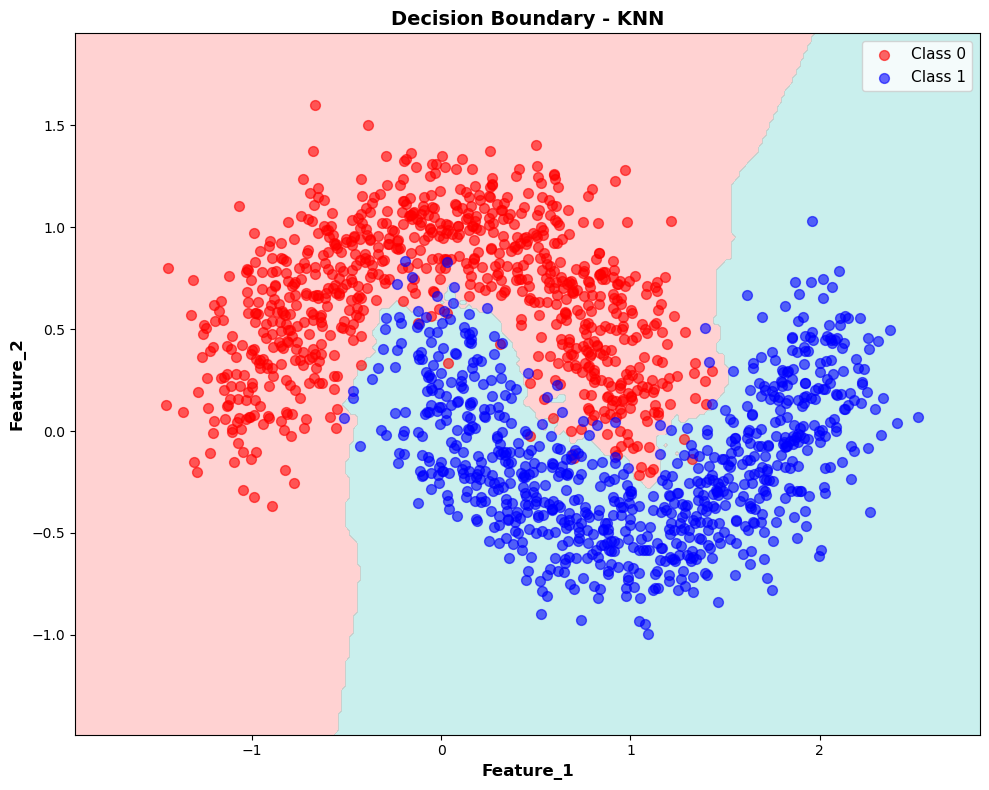

In [12]:
h = 0.02
x_min, x_max = x_test[:, 0].min() - 0.5, x_test[:, 0].max() + 0.5
y_min, y_max = x_test[:, 1].min() - 0.5, x_test[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = np.array([predict(np.array([xx[i, j], yy[i, j]]), k=4)
              for i in range(xx.shape[0]) for j in range(xx.shape[1])])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(xx, yy, Z, alpha=0.3, levels=[0, 0.5, 1], colors=['#FF6B6B', '#4ECDC4'])
ax.scatter(x_train[y_train == 0, 0], x_train[y_train == 0, 1], 
           c='red', marker='o', label='Class 0', alpha=0.6, s=50)
ax.scatter(x_train[y_train == 1, 0], x_train[y_train == 1, 1], 
           c='blue', marker='o', label='Class 1', alpha=0.6, s=50)
ax.set_xlabel('Feature_1', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature_2', fontsize=12, fontweight='bold')
ax.set_title('Decision Boundary - KNN', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()